Data Analysis and Machine Learning Modeling for Insurance Customer Classification

## Data Understanding

**Load data di Google Colab**

*dataset berikut : https://drive.google.com/file/d/15fPi0IimBYIsR_42dywgGKJqiEhasZ4F/view?usp=sharing*

In [ ]:
import pandas as pd

url = 'https://drive.google.com/uc?id=15fPi0IimBYIsR_42dywgGKJqiEhasZ4F'
data = pd.read_csv(url)

# Tampilkan 5 data teratas
data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Insight:


**Telaah Data**

Cek struktur dan tipe data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Insight:

Cek statistik deskriptif

In [ ]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Insight:

Cek Missing Values

In [ ]:
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Insight:

Cek Outlier pakai Boxplot

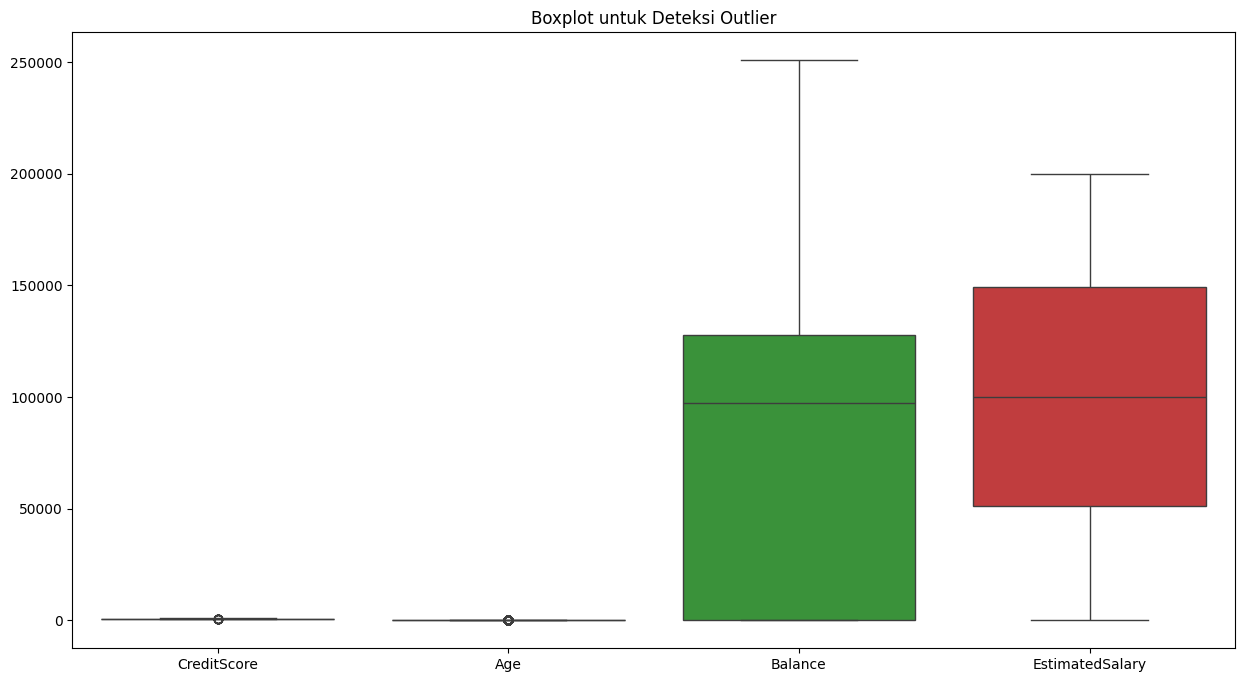

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.boxplot(data=data[['CreditScore', 'Age', 'Balance', 'EstimatedSalary']])
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()


Insight:

Cek Anomali Data

In [ ]:
# Distribusi target
data['Exited'].value_counts(normalize=True)

# Cek nilai unik untuk fitur penting
print(data['Geography'].value_counts())
print(data['Gender'].value_counts())


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


## Data Preproccesing

Membersihkan Data

Drop kolom tidak relevan

In [ ]:
# Kolom RowNumber, CustomerId, dan Surname tidak berpengaruh terhadap prediksi
data_cleaned = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


Cek ulang missing value dan duplikat

In [ ]:
# Missing value
print(data_cleaned.isnull().sum())

# Duplikat
print(data_cleaned.duplicated().sum())


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


Handling outlier bisa menggunakan IQR/clip/normalisasi

In [ ]:
# Batasi outlier kolom 'Age' berdasarkan IQR
Q1 = data_cleaned['Age'].quantile(0.25)
Q3 = data_cleaned['Age'].quantile(0.75)
IQR = Q3 - Q1
data_cleaned = data_cleaned[(data_cleaned['Age'] >= Q1 - 1.5 * IQR) & (data_cleaned['Age'] <= Q3 + 1.5 * IQR)]

### Exploratory Data Analysis (EDA)

Korelasi numerik terhadap target Exited


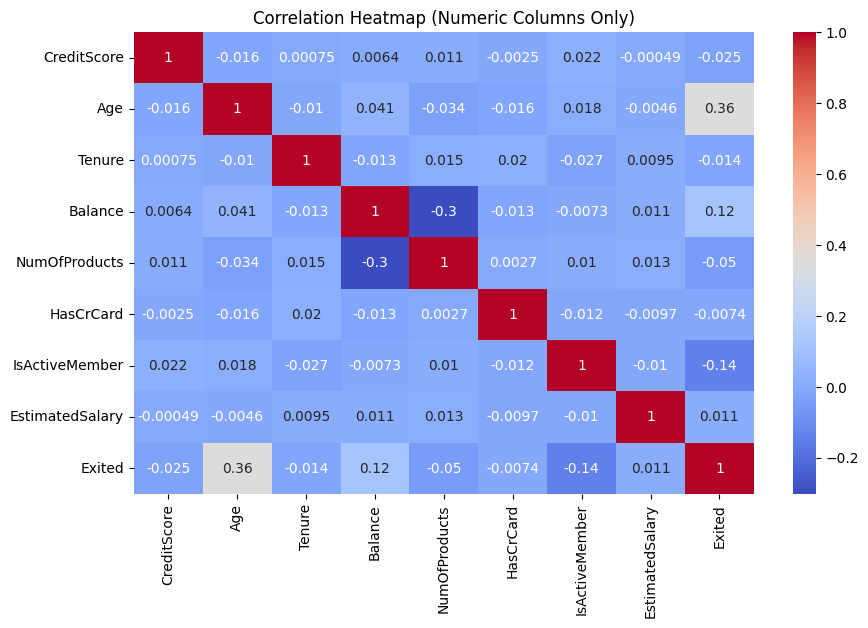

In [ ]:
# Select only numeric columns for correlation calculation
numeric_data_cleaned = data_cleaned.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

Visualisasi distribusi churn per fitur

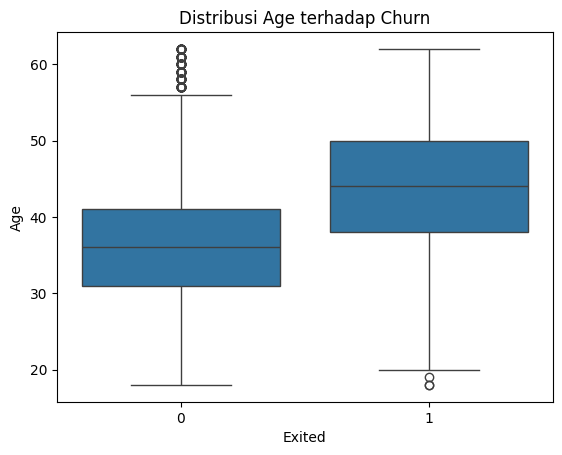

In [ ]:
# Distribusi Age vs Churn
sns.boxplot(x='Exited', y='Age', data=data_cleaned)
plt.title('Distribusi Age terhadap Churn')
plt.show()


Feature Importance (pakai Random Forest sebagai baseline):

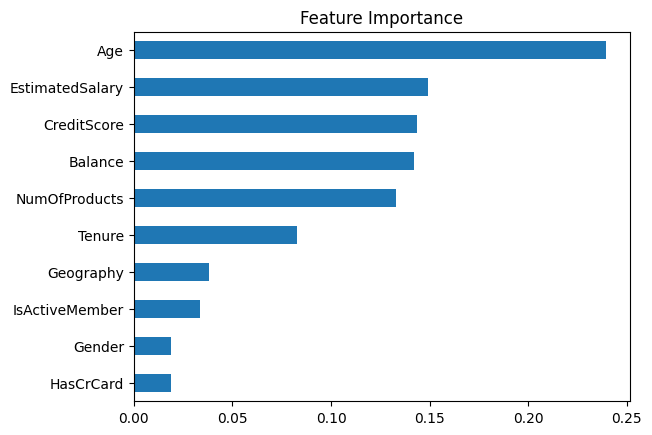

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical: Geography, Gender
data_encoded = data_cleaned.copy()
le_geo = LabelEncoder()
le_gender = LabelEncoder()
data_encoded['Geography'] = le_geo.fit_transform(data_encoded['Geography'])
data_encoded['Gender'] = le_gender.fit_transform(data_encoded['Gender'])

# Split fitur dan label
X = data_encoded.drop(columns='Exited')
y = data_encoded['Exited']

# Random Forest
rf = RandomForestClassifier()
rf.fit(X, y)

# Visualisasi Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()


Menentukan Label Data

In [ ]:
# Cek distribusi label
data_cleaned['Exited'].value_counts(normalize=True)


,proportion
Exited,
0,0.796287
1,0.203713


## Modelling

Pisahkan fitur dan label

In [ ]:
X = data_encoded.drop(columns='Exited')
y = data_encoded['Exited']


Split Data (75% training, 25% testing)

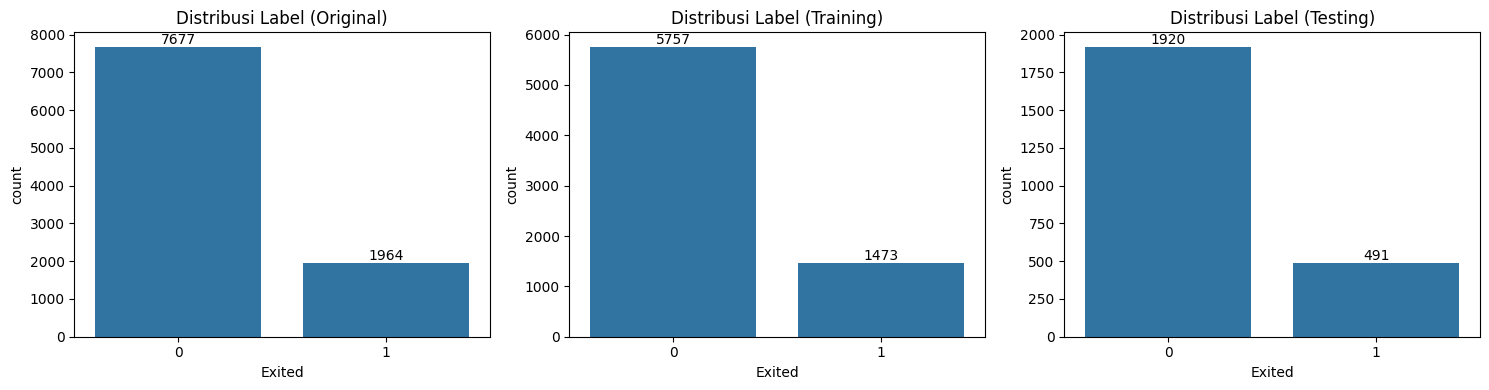

Proporsi label pada dataset asli:
Exited
0    79.628669
1    20.371331
Name: proportion, dtype: float64

Proporsi label pada data training:
Exited
0    79.626556
1    20.373444
Name: proportion, dtype: float64

Proporsi label pada data testing:
Exited
0    79.635006
1    20.364994
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Menampilkan distribusi label sebelum dan sesudah split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi label di data awal
sns.countplot(x=y, ax=axes[0])
axes[0].set_title('Distribusi Label (Original)')
axes[0].bar_label(axes[0].containers[0])

# Distribusi label di data training
sns.countplot(x=y_train, ax=axes[1])
axes[1].set_title('Distribusi Label (Training)')
axes[1].bar_label(axes[1].containers[0])

# Distribusi label di data testing
sns.countplot(x=y_test, ax=axes[2])
axes[2].set_title('Distribusi Label (Testing)')
axes[2].bar_label(axes[2].containers[0])

plt.tight_layout()
plt.show()

# Menampilkan proporsi dalam persentase
print("Proporsi label pada dataset asli:")
print(y.value_counts(normalize=True) * 100)

print("\nProporsi label pada data training:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporsi label pada data testing:")
print(y_test.value_counts(normalize=True) * 100)


Model Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


k-Nearest Neighbors (k-NN) Classifier

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train_knn)
y_pred_knn = knn_model.predict(X_test_knn)


## Evaluation Model

Import Metric & Evaluasi Decision Tree

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Decision Tree ===")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Akurasi:", accuracy_score(y_test, y_pred_dt))


=== Decision Tree ===
[[1688  232]
 [ 247  244]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1920
           1       0.51      0.50      0.50       491

    accuracy                           0.80      2411
   macro avg       0.69      0.69      0.69      2411
weighted avg       0.80      0.80      0.80      2411

Akurasi: 0.8013272501036914


Evaluasi k-NN

In [ ]:
print("=== k-NN ===")
print(confusion_matrix(y_test_knn, y_pred_knn))
print(classification_report(y_test_knn, y_pred_knn))
print("Akurasi:", accuracy_score(y_test_knn, y_pred_knn))


=== k-NN ===
[[1822   98]
 [ 310  181]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1920
           1       0.65      0.37      0.47       491

    accuracy                           0.83      2411
   macro avg       0.75      0.66      0.68      2411
weighted avg       0.81      0.83      0.81      2411

Akurasi: 0.8307756117793447


Perbandingan Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hitung metrik untuk Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Hitung metrik untuk k-NN
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)
knn_precision = precision_score(y_test_knn, y_pred_knn)
knn_recall = recall_score(y_test_knn, y_pred_knn)
knn_f1 = f1_score(y_test_knn, y_pred_knn)

# Tampilkan hasil perbandingan
print("=== Perbandingan Model ===")
print(f"Decision Tree -> Accuracy: {dt_accuracy:.2f}, Precision: {dt_precision:.2f}, Recall: {dt_recall:.2f}, F1-Score: {dt_f1:.2f}")
print(f"k-NN          -> Accuracy: {knn_accuracy:.2f}, Precision: {knn_precision:.2f}, Recall: {knn_recall:.2f}, F1-Score: {knn_f1:.2f}")

# Tentukan model terbaik berdasarkan F1-Score
if dt_f1 > knn_f1:
    print("\n Model terbaik adalah: Decision Tree (berdasarkan F1-Score lebih tinggi)")
elif knn_f1 > dt_f1:
    print("\n Model terbaik adalah: k-NN (berdasarkan F1-Score lebih tinggi)")
else:
    print("\n⚖️ Kedua model memiliki F1-Score yang sama, bisa dipilih berdasarkan kebutuhan bisnis.")

=== Perbandingan Model ===
Decision Tree -> Accuracy: 0.80, Precision: 0.51, Recall: 0.50, F1-Score: 0.50
k-NN          -> Accuracy: 0.83, Precision: 0.65, Recall: 0.37, F1-Score: 0.47

 Model terbaik adalah: Decision Tree (berdasarkan F1-Score lebih tinggi)
